# 03 - EDA: Censo 2022 (BA)

Exploração do arquivo `29_BA.parquet` do Censo 2022.

~9 milhões de linhas, 433MB  lido via DuckDB sem carregar na memória.

Destaques: coordenadas **LATITUDE/LONGITUDE**, setor censitário, CEP, espécie e tipo de estabelecimento.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect()
CENSO = "'../data/censo 2022/29_BA.parquet'"

In [ ]:
import xlrd

def load_dictionary(path):
    wb = xlrd.open_workbook(path)
    sh = wb.sheet_by_index(0)
    rows = [sh.row_values(r) for r in range(1, sh.nrows)]

    records = []
    variavel, descricao = '', ''
    for variavel_val, descricao_val, categoria_val in rows:
        if variavel_val:
            variavel, descricao = variavel_val, descricao_val
        if categoria_val:
            records.append({'variavel': variavel, 'descricao': descricao, 'categoria': categoria_val})
        elif variavel_val and not categoria_val:
            records.append({'variavel': variavel, 'descricao': descricao, 'categoria': ''})
    return pd.DataFrame(records).drop_duplicates()

dic = load_dictionary('../data/censo 2022/Dicionario_CNEFE_Censo_2022.xls')
dic

In [2]:
# Schema e amostra
con.execute(f"DESCRIBE SELECT * FROM read_parquet({CENSO}) LIMIT 1").df()

,column_name,column_type,null,key,default,extra
0,COD_UNICO_ENDERECO,BIGINT,YES,None,None,None
1,COD_UF,BIGINT,YES,None,None,None
2,COD_MUNICIPIO,BIGINT,YES,None,None,None
3,COD_DISTRITO,BIGINT,YES,None,None,None
4,COD_SUBDISTRITO,BIGINT,YES,None,None,None
5,COD_SETOR,VARCHAR,YES,None,None,None
6,NUM_QUADRA,BIGINT,YES,None,None,None
7,NUM_FACE,BIGINT,YES,None,None,None
8,CEP,BIGINT,YES,None,None,None
9,DSC_LOCALIDADE,VARCHAR,YES,None,None,None


In [3]:
con.execute(f"SELECT COUNT(*) as total FROM read_parquet({CENSO})").df()

,total
0,9047296


In [4]:
# Amostra
con.execute(f"SELECT * FROM read_parquet({CENSO}) LIMIT 10").df()

,COD_UNICO_ENDERECO,COD_UF,COD_MUNICIPIO,COD_DISTRITO,COD_SUBDISTRITO,COD_SETOR,NUM_QUADRA,NUM_FACE,CEP,DSC_LOCALIDADE,...,VAL_COMP_ELEM5,LATITUDE,LONGITUDE,NV_GEO_COORD,COD_ESPECIE,DSC_ESTABELECIMENTO,COD_INDICADOR_ESTAB_ENDERECO,COD_INDICADOR_CONST_ENDERECO,COD_INDICADOR_FINALIDADE_CONST,COD_TIPO_ESPECI
0,112026678,29,2900801,290080125,29008012500,290080125000007P,0,126,45910000,POUSO ALEGRE,...,None,-17.421301,-39.588591,1,3,NaN,1,<NA>,<NA>,<NA>
1,112026678,29,2900801,290080125,29008012500,290080125000007P,0,126,45910000,POUSO ALEGRE,...,None,-17.421301,-39.588591,1,1,NaN,<NA>,<NA>,<NA>,101
2,192615207,29,2901007,290100705,29010070500,290100705000002P,1,2,45300000,AMARGOSA,...,None,-13.030280,-39.595209,1,1,NaN,<NA>,<NA>,<NA>,103
3,24076305,29,2901007,290100705,29010070500,290100705000029P,0,5,45300000,LAGOA QUEIMADA,...,None,-12.976211,-39.577448,1,1,NaN,<NA>,<NA>,<NA>,101
4,192618976,29,2901007,290100705,29010070500,290100705000045P,4,15,45300000,SANTA RITA,...,None,-13.016349,-39.608956,1,6,DEPOSITO,1,<NA>,<NA>,<NA>
5,192619074,29,2901007,290100705,29010070500,290100705000045P,4,15,45300000,SANTA RITA,...,None,-13.017039,-39.609228,1,1,NaN,<NA>,<NA>,<NA>,101
6,192602843,29,2900702,290070220,29007022000,290070220000001P,1,27,48031000,RIACHO DA GUIA,...,None,-11.956558,-38.377424,1,1,NaN,<NA>,<NA>,<NA>,101
7,23981162,29,2900355,290035505,29003550500,290035505000021P,2,1,48435000,ADUSTINA,...,None,-10.532600,-38.120720,1,1,NaN,<NA>,<NA>,<NA>,101
8,23986724,29,2900405,290040505,29004050500,290040505000015P,2,2,48170000,BARRA,...,None,-11.881363,-38.767607,1,1,NaN,<NA>,<NA>,<NA>,101
9,23986766,29,2900405,290040505,29004050500,290040505000015P,2,4,48170000,BARRA,...,None,-11.881976,-38.766593,1,1,NaN,<NA>,<NA>,<NA>,101


In [5]:
# Valores nulos nas colunas principais
con.execute(f"""
    SELECT
        COUNT(*) FILTER (WHERE LATITUDE IS NULL)          AS lat_nulos,
        COUNT(*) FILTER (WHERE LONGITUDE IS NULL)         AS lon_nulos,
        COUNT(*) FILTER (WHERE CEP IS NULL)               AS cep_nulos,
        COUNT(*) FILTER (WHERE COD_SETOR IS NULL)         AS setor_nulos,
        COUNT(*) FILTER (WHERE COD_ESPECIE IS NULL)       AS especie_nulos,
        COUNT(*) FILTER (WHERE DSC_ESTABELECIMENTO IS NULL) AS estab_nulos
    FROM read_parquet({CENSO})
""").df()

,lat_nulos,lon_nulos,cep_nulos,setor_nulos,especie_nulos,estab_nulos
0,0,0,0,0,0,7631999


In [6]:
# Distribuição por espécie (tipo de domicílio/estabelecimento)
df_especie = con.execute(f"""
    SELECT COD_ESPECIE, COUNT(*) as total
    FROM read_parquet({CENSO})
    GROUP BY COD_ESPECIE
    ORDER BY total DESC
""").df()

print(df_especie)

   COD_ESPECIE    total
0            1  6868847
1            6  1032896
2            3   573839
3            7   466369
4            8    52939
5            4    28315
6            5    16347
7            2     7744


In [7]:
# Cobertura de coordenadas
df_geo = con.execute(f"""
    SELECT NV_GEO_COORD, COUNT(*) as total
    FROM read_parquet({CENSO})
    GROUP BY NV_GEO_COORD
    ORDER BY total DESC
""").df()

print(df_geo)

   NV_GEO_COORD    total
0             1  8721710
1             2   221530
2             3    65260
3             4    36796
4             5     1073
5             6      927


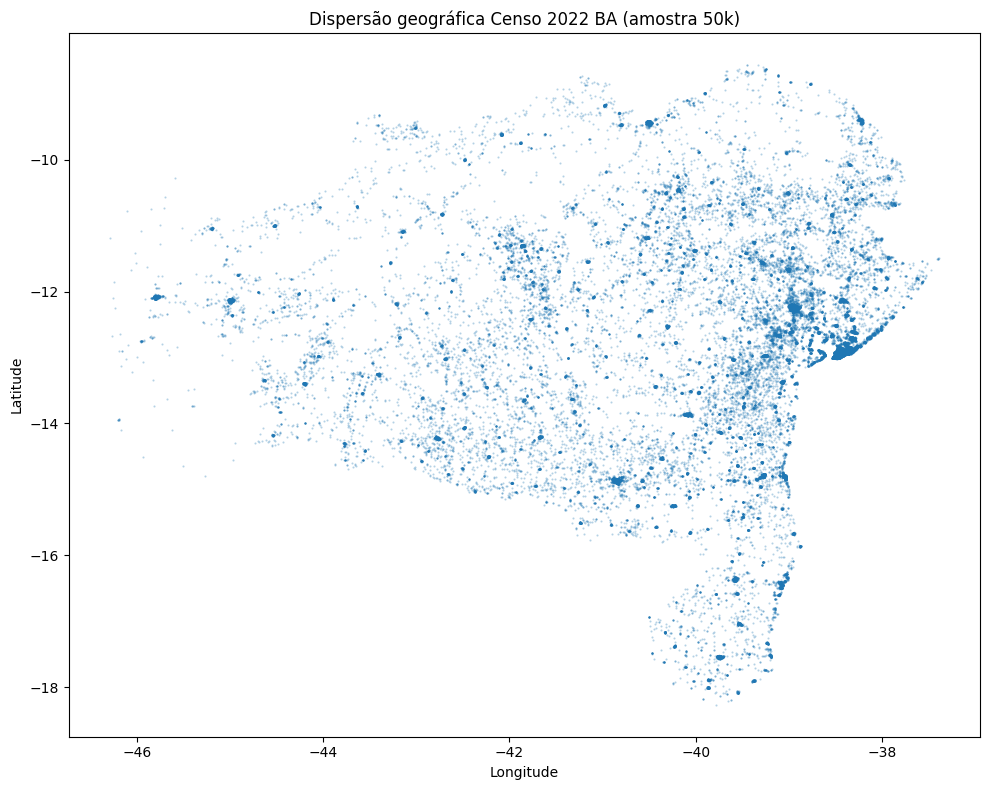

In [10]:
# Dispersão geográfica — amostra de 50k pontos
df_sample = con.execute(f"""
    SELECT LATITUDE, LONGITUDE, COD_ESPECIE
    FROM read_parquet({CENSO})
    WHERE LATITUDE IS NOT NULL AND LONGITUDE IS NOT NULL
    USING SAMPLE 50000
""").df()

plt.figure(figsize=(10, 8))
plt.scatter(df_sample['LONGITUDE'], df_sample['LATITUDE'], s=0.3, alpha=0.3)
plt.title('Dispersão geográfica Censo 2022 BA (amostra 50k)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('../outputs/figures/censo_dispersao_geo.png', dpi=150)
plt.show()

In [9]:
# Top municípios com mais registros
con.execute(f"""
    SELECT COD_MUNICIPIO, COUNT(*) as total
    FROM read_parquet({CENSO})
    GROUP BY COD_MUNICIPIO
    ORDER BY total DESC
    LIMIT 15
""").df()

,COD_MUNICIPIO,total
0,2927408,1390897
1,2910800,359076
2,2905701,216243
3,2933307,199847
4,2918407,127731
5,2913606,113594
6,2914802,112090
7,2919207,111385
8,2925303,105378
9,2918001,89569
